In [1]:
import os
from pathlib import Path
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
    sys.path.insert(0, os.getcwd())

PROJECT_ROOT = Path.cwd()

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
BEATMAPS_DIR = DATA_DIR / "beatmaps"
COLLECTIONS_DIR = DATA_DIR / "collections"

DIFFICULTY_CACHE_PATH = DATA_DIR / "difficulty_attributes_cache.json"
BEATMAPS_PATH = BEATMAPS_DIR / "beatmaps.parquet"
COLLECTIONS_PATH = COLLECTIONS_DIR / "collections.parquet"

Loaded 173,591 beatmaps

STAR RATING STATISTICS
Mean:    5.17
Median:  5.23
Std Dev: 2.20
Range:   0.14 - 191.88

DISTRIBUTION
0-1     :      69 (  0.0%)
1-2     :  10,064 (  5.8%)
2-3     :  20,905 ( 12.0%)
3-4     :  21,455 ( 12.4%)
4-5     :  26,198 ( 15.1%)
5-6     :  34,559 ( 19.9%)
6-7     :  29,074 ( 16.7%)
7-8     :  17,955 ( 10.3%)
8-9     :   8,413 (  4.8%)
9-10    :   3,293 (  1.9%)
10-11   :     927 (  0.5%)
11-12   :     295 (  0.2%)
12-13   :     140 (  0.1%)
13-14   :      71 (  0.0%)
14+     :     173 (  0.1%)


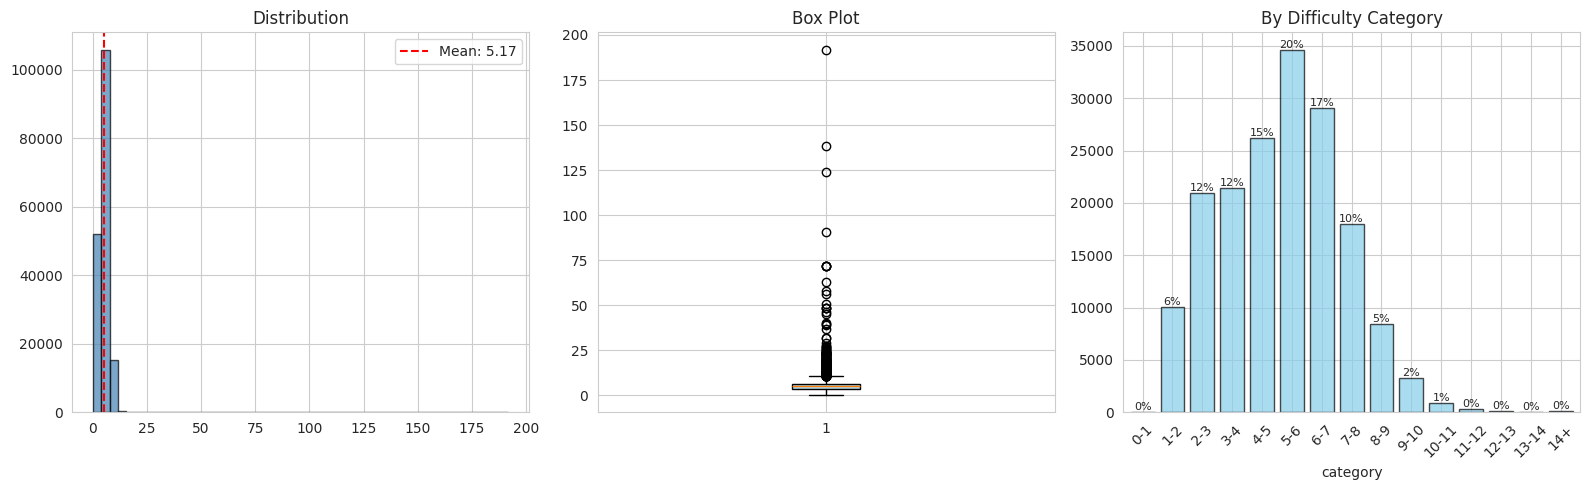

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

with open(DIFFICULTY_CACHE_PATH, 'r') as f:
    difficulty_cache = json.load(f)

data = []
for _, seqs in difficulty_cache.items():
    if seqs:
        max_key = str(max(map(int, seqs.keys())))
        if 'stars' in seqs[max_key]:
            data.append(seqs[max_key]['stars'])

star_df = pd.DataFrame({'stars': data})
star_df = star_df[star_df['stars'] < 14]

print(f"Loaded {len(star_df):,} beatmaps (< 14 stars)")

stats = star_df['stars'].describe()
print("\nSTAR RATING STATISTICS")
print(f"Mean:    {stats['mean']:.2f}")
print(f"Median:  {stats['50%']:.2f}")
print(f"Std Dev: {stats['std']:.2f}")
print(f"Range:   {stats['min']:.2f} - {stats['max']:.2f}")

bins = range(0, 15)
labels = [f"{i}-{i+1}" for i in range(0, 14)]
star_df['category'] = pd.cut(star_df['stars'], bins=bins, labels=labels, right=False)
cat_counts = star_df['category'].value_counts().sort_index()

print("\nDISTRIBUTION")
for label, count in cat_counts.items():
    pct = count / len(star_df) * 100
    print(f"{label:8}: {count:7,} ({pct:5.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(star_df['stars'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(stats['mean'], color='red', linestyle='--', label=f"Mean: {stats['mean']:.2f}")
axes[0].set_title('Distribution')
axes[0].legend()

axes[1].boxplot(star_df['stars'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Box Plot')

cat_counts.plot(kind='bar', ax=axes[2], color='skyblue', alpha=0.7, edgecolor='black', width=0.8)
axes[2].set_title('By Difficulty Category')
axes[2].tick_params(axis='x', rotation=45)

for i, v in enumerate(cat_counts):
    axes[2].text(i, v, f'{v/len(star_df)*100:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()